In [12]:
# Importing required libraries for data analysis and visualization
import pandas as pd              # For data manipulation and analysis
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt # For plotting graphs
import seaborn as sns           # For advanced visualizations

In [13]:
# Loading the dataset into a pandas DataFrame
df = pd.read_csv("quikr_car.csv")

# Display first 5 rows to understand structure
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [14]:
# Check number of rows and columns
df.shape

# Get information about data types and missing values
df.info()

# Get statistical summary of numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


,name,company,year,Price,kms_driven,fuel_type
count,892,892,892,892,840,837
unique,525,48,61,274,258,3
top,Honda City,Maruti,2015,Ask For Price,"45,000 kms",Petrol
freq,13,235,117,35,30,440


In [15]:
# Removing rows where price is not available (e.g., 'Ask For Price')
df = df[df['Price'] != 'Ask For Price']

# Removing commas from price and converting it to integer
df['Price'] = df['Price'].str.replace(',', '').astype(int)

# Keeping only rows where year is numeric
df = df[df['year'].str.isnumeric()]

# Converting year to integer type
df['year'] = df['year'].astype(int)

# Extract numeric part (removing 'kms driven' text)
df['kms_driven'] = df['kms_driven'].str.split(' ').str[0]

# Removing commas
df['kms_driven'] = df['kms_driven'].str.replace(',', '')

# Keeping only numeric values
df = df[df['kms_driven'].str.isnumeric()]

# Converting to integer
df['kms_driven'] = df['kms_driven'].astype(int)

# Removing rows where fuel type is missing
df = df[~df['fuel_type'].isna()]

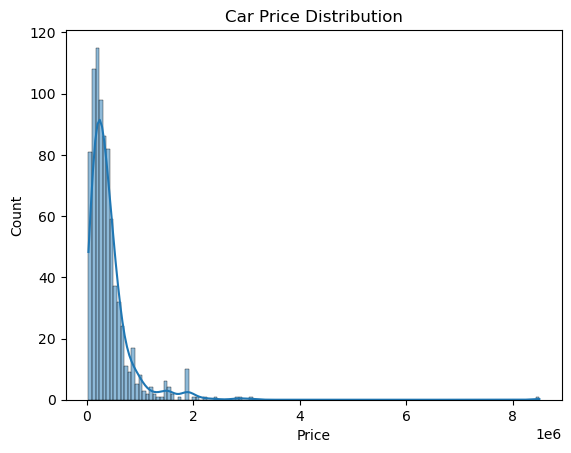

In [16]:
# Plotting histogram to understand distribution of car prices
sns.histplot(df['Price'], kde=True)

# Adding title
plt.title("Car Price Distribution")

# Display plot
plt.show()

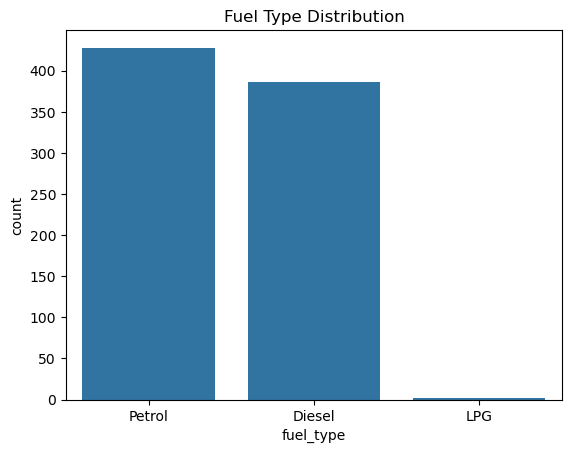

In [17]:
# Count plot to see number of cars for each fuel type
sns.countplot(x='fuel_type', data=df)

# Title of graph
plt.title("Fuel Type Distribution")

# Display plot
plt.show()

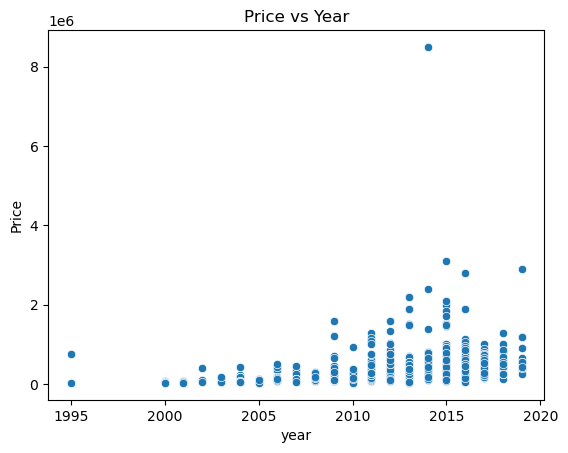

In [18]:
# Scatter plot to analyze relationship between year and price
sns.scatterplot(x='year', y='Price', data=df)

# Title
plt.title("Price vs Year")

# Show plot
plt.show()

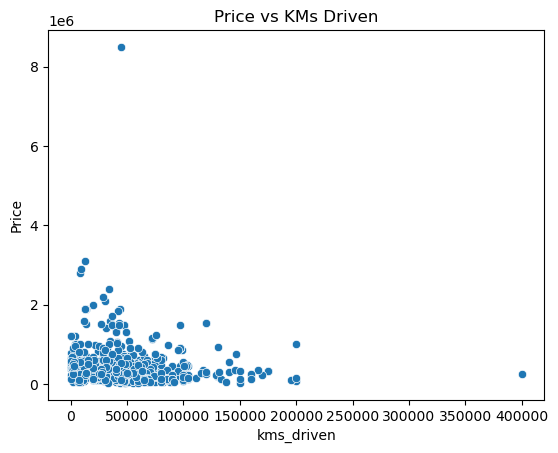

In [19]:
# Scatter plot to analyze how usage affects price
sns.scatterplot(x='kms_driven', y='Price', data=df)

# Title
plt.title("Price vs KMs Driven")

# Show plot
plt.show()

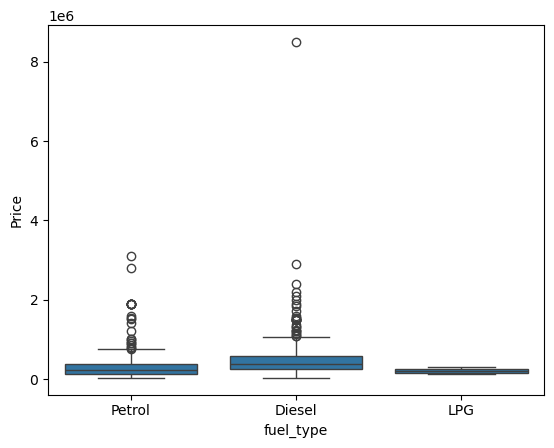

In [20]:
# Boxplot to compare price distribution across fuel types
sns.boxplot(x='fuel_type', y='Price', data=df)

# Show plot
plt.show()

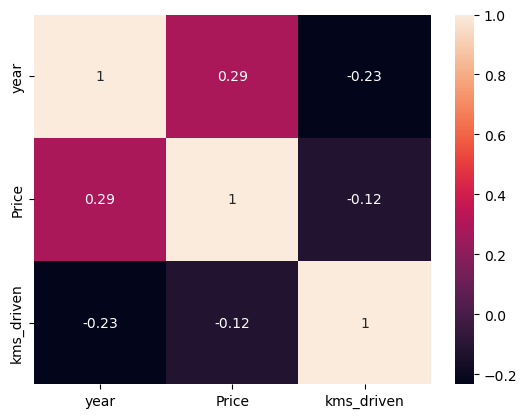

In [21]:
# Calculate correlation matrix for numerical features
corr = df.corr(numeric_only=True)

# Plot heatmap to visualize correlations
sns.heatmap(corr, annot=True)

# Display plot
plt.show()

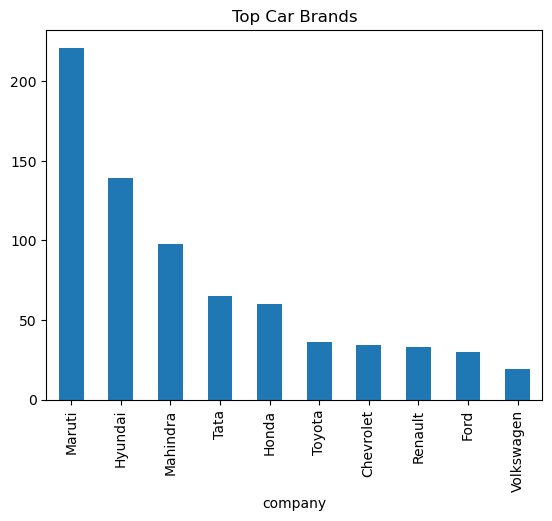

In [22]:
# Count top 10 car brands
df['company'].value_counts().head(10).plot(kind='bar')

# Title
plt.title("Top Car Brands")

# Show plot
plt.show()